# Colorectal Histology 6
Vou seguir o mesmo padrão do MNIST, mas com histologia colorretal. O colorectal_histology é um dataset de imagens de Classificação de texturas na histologia do câncer colorretal. Cada exemplo é uma imagem RGB de 150 x 150 x 3 de uma das 8 classes.  
No quinto modelo, a acurácia do treino subiu para ~89%, na validação, a acurácia ficou em ~86%, a mais alta até o momento.  
Nesta tentativa, visto que a acurácia se manteve subindo, vou experimentar apenas aumentar ainda mais a quantidade de épocas, bom... isso vai demorar bastante, visto que demorou cerca de uma hora para o notebook anterior.  

<small>**OBS:** É necessário baixar tensorflow-datasets (`pip install tensorflow-datasets`).  

Site: <https://www.tensorflow.org/datasets/catalog/colorectal_histology>  
</small>

## Importando as bibliotecas

In [1]:
!pip install tensorflow-datasets tensorflow

In [45]:
import tensorflow as tf
import keras
import matplotlib
import numpy as np

import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import utils as np_utils
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import cv2
import matplotlib.pyplot as plt

In [3]:
# O dataset não vem dividido, então vou pegar ele e depois fazer a divisão
dataset = tfds.load('colorectal_histology', split = 'train', as_supervised = True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/colorectal_histology/incomplete.L4SQMM_2.0.0/colorectal_histology-train.tf…

Dataset colorectal_histology downloaded and prepared to /root/tensorflow_datasets/colorectal_histology/2.0.0. Subsequent calls will reuse this data.


In [4]:
# Ele tem o tamanho de 5.000 imagens pelo que eu vi no site do tensorflow
# Tambem, ele vem em uma tupla (imagem, label), vou extrair as imagens e labels em arrays separados
# depois usar o train_test_split para separar a divisão para treino e teste
imagens = np.array([
    img.numpy()
    for img, label in dataset
])
labels = np.array([
    label.numpy()
    for img, label in dataset
])

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    # Divisao de 80/20, sendo 80% para treino e 20% para teste
    imagens, labels, test_size = 0.2, random_state = 42
)

In [6]:
# Diferente da aula, nao vou precisar usar o reshape
X_treino = X_treino.astype('float32')
X_teste = X_teste.astype('float32')

In [7]:
# Agora vou normalizar eles
X_treino /= 255
X_teste /= 255
X_treino.max(), X_treino.min()

(np.float32(1.0), np.float32(0.0))

In [8]:
# Vou transformar as saidas para categoricos, no codigo da aula ele usa 10, porque sao 10 classes, no meu caso sao 8 classes
y_treino = np_utils.to_categorical(y_treino , 8)
y_teste = np_utils.to_categorical(y_teste, 8)
y_treino, y_teste

(array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [1., 0., 0., ..., 0., 0., 0.]]),
 array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.]]))

In [9]:
y_treino[2]

array([0., 1., 0., 0., 0., 0., 0., 0.])

In [10]:
X_treino.shape, X_teste.shape

((4000, 150, 150, 3), (1000, 150, 150, 3))

Text(0.5, 1.0, 'Classe [0. 1. 0. 0. 0. 0. 0. 0.]')

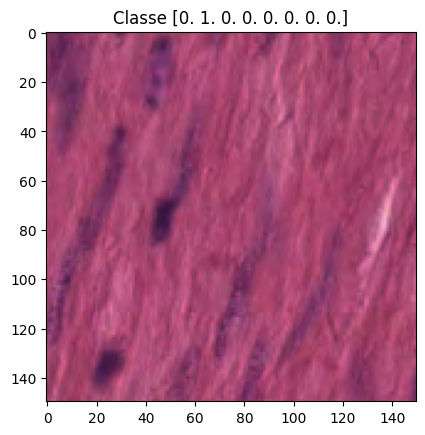

In [11]:
plt.imshow(X_treino[0])
plt.title('Classe ' + str(y_treino[0]))

In [12]:
gerador_treino = ImageDataGenerator(
    rotation_range=7,
    horizontal_flip=True,
    shear_range=0.2,
    height_shift_range=0.07,
    zoom_range=0.2
)
gerador_teste = ImageDataGenerator()

In [13]:
base_treino = gerador_treino.flow(X_treino, y_treino)
base_teste = gerador_teste.flow(X_teste, y_teste, shuffle = False)

In [14]:
# Agora que tem os dados prontos, vou começar montar a rede neural,
rede_neural = Sequential()

# Aumentar para 128, ja que as imagens agora tem a dimensao 128x128
rede_neural.add(InputLayer(shape =(150, 150, 3)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

# Aumentar o filtro de uma das camadas convilucionais
rede_neural.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

# Aumentar o filtro de uma das camadas convilucionais
rede_neural.add(Conv2D(filters = 96, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Flatten())
# Adicionei Dropout depois do Flatten
rede_neural.add(Dropout(0.5))
rede_neural.add(Dense(units = 256, activation = 'relu'))
rede_neural.add(Dropout(0.5))
rede_neural.add(Dense(units = 8, activation = 'softmax'))

In [15]:
rede_neural.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,102,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,180,328 (27.39 MB)

 Trainable params: 7,179,944 (27.39 MB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
# Agora vou compilar a rede neural
# Vou usar a função de perda categorical_crossentropy, o otimizador adam e como métrica vou usar acurácia
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [17]:
# Finalmente, vou realizar o treino dela, vou aumentar as epocas para 100
rede_neural.fit(base_treino, epochs = 250, validation_data = base_teste)

Epoch 1/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 189ms/step - accuracy: 0.4720 - loss: 4.6971 - val_accuracy: 0.1280 - val_loss: 55.3589
Epoch 2/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 173ms/step - accuracy: 0.5285 - loss: 1.1987 - val_accuracy: 0.1280 - val_loss: 53.2224
Epoch 3/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.5885 - loss: 1.0836 - val_accuracy: 0.1660 - val_loss: 22.7558
Epoch 4/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.5938 - loss: 1.0504 - val_accuracy: 0.3220 - val_loss: 6.4898
Epoch 5/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.6340 - loss: 0.9361 - val_accuracy: 0.5790 - val_loss: 1.7151
Epoch 6/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.6342 - loss: 0.9407 - val_accuracy: 0.5360 - val_loss: 2.0518
Epoch 7/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.6727 - loss: 0.8889 - val_accuracy: 0.5840 - val_loss: 1.7679
Epoch 8/250
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.659

In [18]:
resultado = rede_neural.evaluate(X_teste, y_teste)
resultado

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8320 - loss: 1.4510


[1.4509570598602295, 0.8320000171661377]

In [31]:
previsao = rede_neural.predict(X_teste)
previsao

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


array([[1.0583726e-22, 1.0000000e+00, 3.2426878e-16, ..., 9.7052393e-32,
        9.4127027e-33, 0.0000000e+00],
       [4.1992685e-14, 3.8332866e-24, 1.6021871e-17, ..., 1.0000000e+00,
        1.8216880e-44, 0.0000000e+00],
       [1.0000000e+00, 0.0000000e+00, 2.8698207e-21, ..., 5.5011764e-26,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [8.1843874e-09, 1.4403547e-07, 1.1843627e-13, ..., 5.4631570e-09,
        8.5124636e-01, 1.4873421e-01],
       [6.7853621e-06, 9.9402088e-01, 5.8966927e-04, ..., 1.3680376e-07,
        1.8277598e-09, 7.8124960e-23],
       [2.0000088e-11, 1.0646699e-21, 1.9370739e-15, ..., 1.0000000e+00,
        6.2520613e-40, 0.0000000e+00]], dtype=float32)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/3

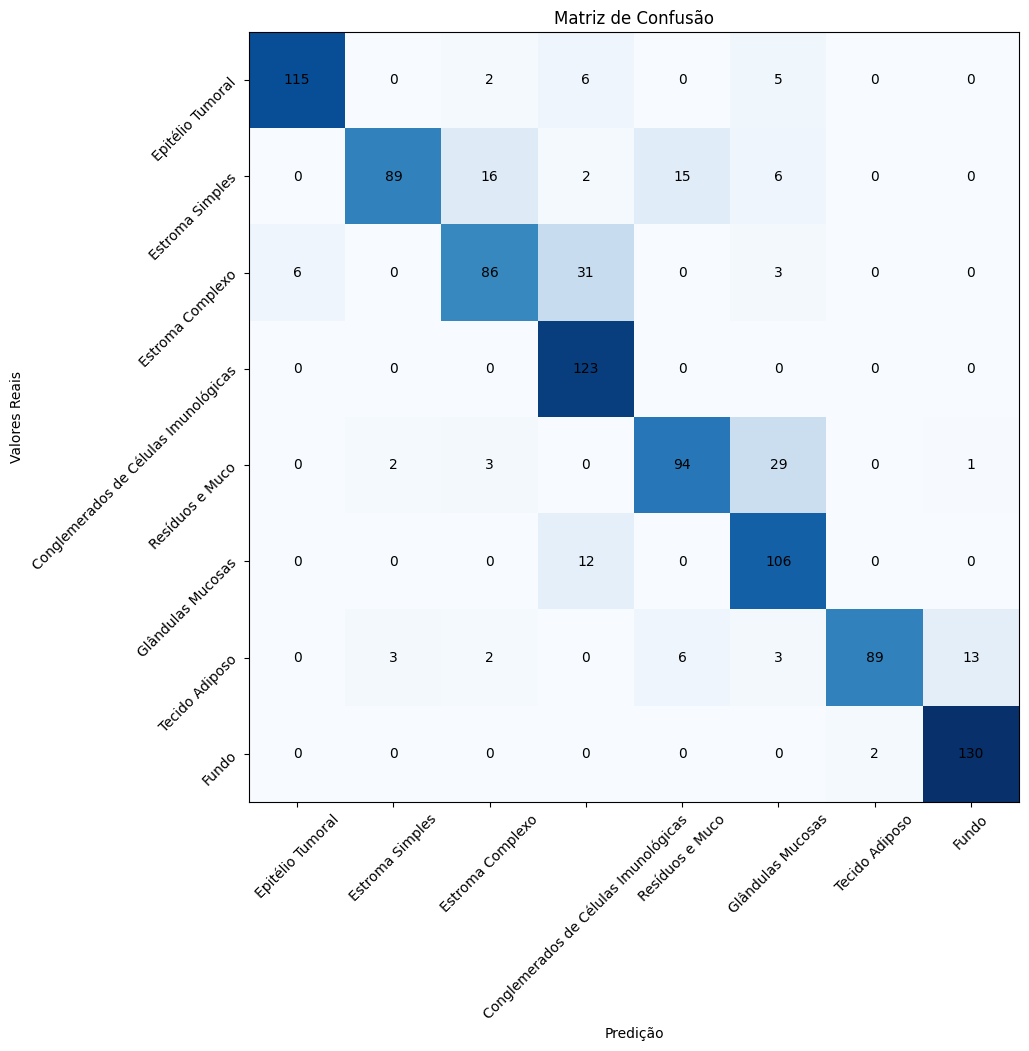

In [29]:
confusion_matrix(y_teste.argmax(axis = 1), rede_neural.predict(X_teste).argmax(axis = 1))
plt.figure(figsize = (10, 10))
plt.imshow(confusion_matrix(y_teste.argmax(axis = 1), rede_neural.predict(X_teste).argmax(axis = 1)), cmap = 'Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Predição')
plt.ylabel('Valores Reais')
plt.xticks(
    [0, 1, 2, 3, 4, 5, 6, 7],
    [
        'Epitélio Tumoral',
        'Estroma Simples',
        'Estroma Complexo',
        'Conglemerados de Células Imunológicas',
        'Resíduos e Muco',
        'Glândulas Mucosas',
        'Tecido Adiposo',
        'Fundo'
    ],
    rotation=45)
plt.yticks(
    [0, 1, 2, 3, 4, 5, 6, 7],
    [
        'Epitélio Tumoral',
        'Estroma Simples',
        'Estroma Complexo',
        'Conglemerados de Células Imunológicas',
        'Resíduos e Muco',
        'Glândulas Mucosas',
        'Tecido Adiposo',
        'Fundo'
    ],
    rotation=45)
for i in range(8):
    for j in range(8):
        plt.text(j, i, confusion_matrix(y_teste.argmax(axis = 1), rede_neural.predict(X_teste).argmax(axis = 1))[i, j], ha = 'center', va = 'center', color = 'black')
plt.show()

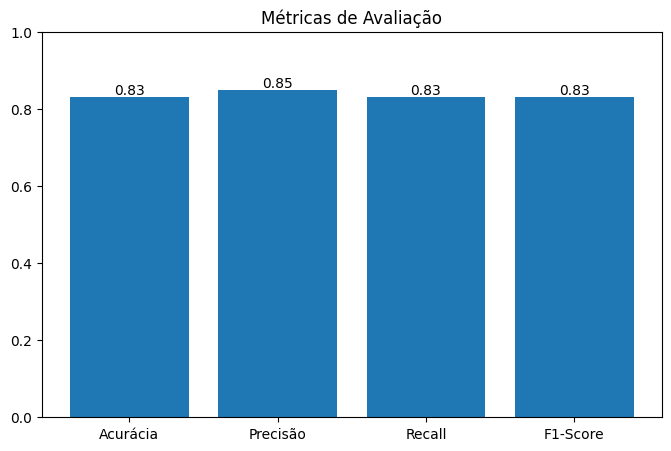

In [42]:
plt.figure(figsize = (8, 5))
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

y_teste_tbl = y_teste.argmax(axis = 1)
previsao_tbl = previsao.argmax(axis = 1)

valores = [
    accuracy_score(y_teste_tbl, previsao_tbl),
    precision_score(y_teste_tbl, previsao_tbl, average = 'weighted'),
    recall_score(y_teste_tbl, previsao_tbl, average = 'weighted'),
    f1_score(y_teste_tbl, previsao_tbl, average = 'weighted')
]
plt.bar(metricas, valores)
plt.title('Métricas de Avaliação')
plt.ylim(0, 1)
for i in range(len(metricas)):
    plt.text(i, valores[i], str(round(valores[i], 2)), ha = 'center', va = 'bottom')
plt.show()

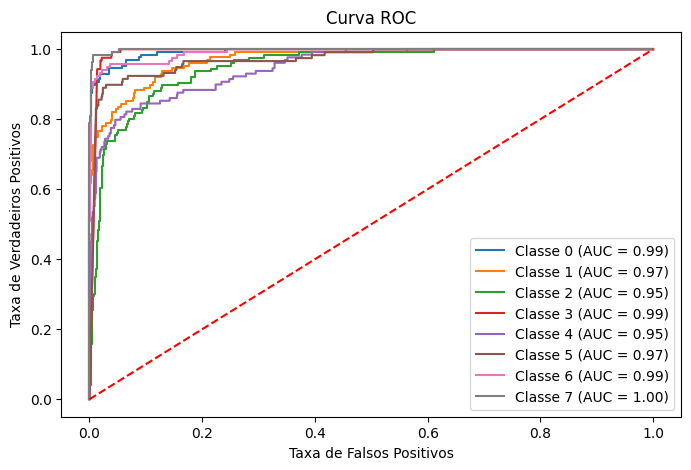

In [46]:
plt.figure(figsize=(8, 5))
y_bin = label_binarize(y_teste, classes=list(range(8)))
for i in range(8):
    fpr, tpr, _ = roc_curve(y_bin[:, i], previsao[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Classe {i} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color = 'red', linestyle = '--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()